In [8]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

from geoai.utils_ds.preprocessing_ops import PreProcessingOperations
from geoai.utils_ds.visualize_ops import VisualizeOperations
from geoai.utils_ml.model_ops import ModelOperations


pre_ops = PreProcessingOperations()
vis_ops = VisualizeOperations()
model_ops = ModelOperations()

In [9]:
# Load the data
X_train = pd.read_csv("csv_files/X_train_fe.csv")
X_test = pd.read_csv("csv_files/X_test_fe.csv")
y_train = pd.read_csv("csv_files/y_train_encoded.csv")
y_test = pd.read_csv("csv_files/y_test_encoded.csv")
X_train.head()

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2,NDVI_binary_non_veg,NDVI_binary_veg,NDVI_categorized_encoded
0,5.860786,6.297109,5.780744,8.094989,7.588999,0.599142,-0.284788,0.002541,34.348815,36.906012,...,0.019287,0.358971,-0.170628,0.001523,0.081104,-0.000724,6.459135e-06,0,1,2
1,5.968708,6.320768,5.942799,8.012239,7.596894,0.574505,-0.229186,0.002224,35.625470,37.726818,...,0.016899,0.330056,-0.131668,0.001278,0.052526,-0.000510,4.948067e-06,0,1,2
2,7.071573,7.111240,7.145984,7.234177,7.431537,0.043156,0.093877,0.000127,50.007150,50.287656,...,0.000947,0.001862,0.004051,0.000006,0.008813,0.000012,1.625104e-08,1,0,0
3,5.897703,6.305362,5.981414,8.085025,7.627057,0.578262,-0.255084,0.002435,34.782903,37.187156,...,0.018575,0.334387,-0.147505,0.001408,0.065068,-0.000621,5.931214e-06,0,1,2
4,6.999970,7.010613,7.051856,7.113956,7.361375,0.030594,0.116155,0.000098,48.999577,49.074077,...,0.000724,0.000936,0.003554,0.000003,0.013492,0.000011,9.665850e-09,1,0,0


In [10]:
# scale the data
X_train_fe_scaled, X_test_fe_scaled = pre_ops.scale_to_minmax(X_train, X_test)
X_train_fe_scaled.head()

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2,NDVI_binary_non_veg,NDVI_binary_veg,NDVI_categorized_encoded
0,0.028792,0.092959,0.036666,0.811104,0.252389,0.998145,0.074872,0.958466,0.023717,0.048942,...,0.967258,0.996101,0.115180,0.975468,0.741622,0.087732,0.918597,0.0,1.0,1.0
1,0.070846,0.103193,0.096423,0.752344,0.257980,0.959140,0.165553,0.838990,0.058899,0.072450,...,0.847577,0.915867,0.281023,0.819191,0.480302,0.279052,0.703698,0.0,1.0,1.0
2,0.500597,0.445141,0.540090,0.199853,0.140895,0.117894,0.692431,0.048801,0.455225,0.432197,...,0.048329,0.005168,0.858749,0.006760,0.080586,0.745577,0.002311,1.0,0.0,0.0
3,0.043177,0.096529,0.110662,0.804029,0.279338,0.965088,0.123316,0.918495,0.035680,0.056994,...,0.931568,0.927885,0.213608,0.902424,0.594985,0.179424,0.843518,0.0,1.0,1.0
4,0.472696,0.401611,0.505381,0.114486,0.091216,0.098004,0.728764,0.037811,0.427459,0.397440,...,0.037124,0.002597,0.856630,0.005167,0.123372,0.745088,0.001375,1.0,0.0,0.0


# Reducing Dimensions of the Dataset

Dimensionality reduction is an approach to data compression with the goal of
maintaining most of the relevant information. In practice, feature reduction is
not only used to improve storage space or the computational efficiency of the
learning algorithm but can also improve the predictive performance by reducing
the effect of large numbers of features.

## Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a technique used in data analysis and machine learning to reduce the dimensionality of a dataset while retaining most of its important information. It transforms the original features into a new set of uncorrelated features called principal components.

### Benefits of PCA

- **Dimensionality Reduction**: Reduces the number of features while retaining the most important information, making the data easier to visualize and work with.
- **Noise Reduction**: By focusing on the components with the most variance, PCA can help filter out noise from the data.
- **Improved Performance**: Simplifies models by reducing the number of input features, which can lead to faster training times and improved performance.

### Simple Example

Imagine you have a dataset with many correlated features. PCA can transform these features into a smaller number of uncorrelated components, each representing a combination of the original features that captures the most significant patterns in the data.

In [11]:
# compute for PCA  explained variance
var_exp, cum_var_exp = pre_ops.compute_pca_variance(X_train_fe_scaled)

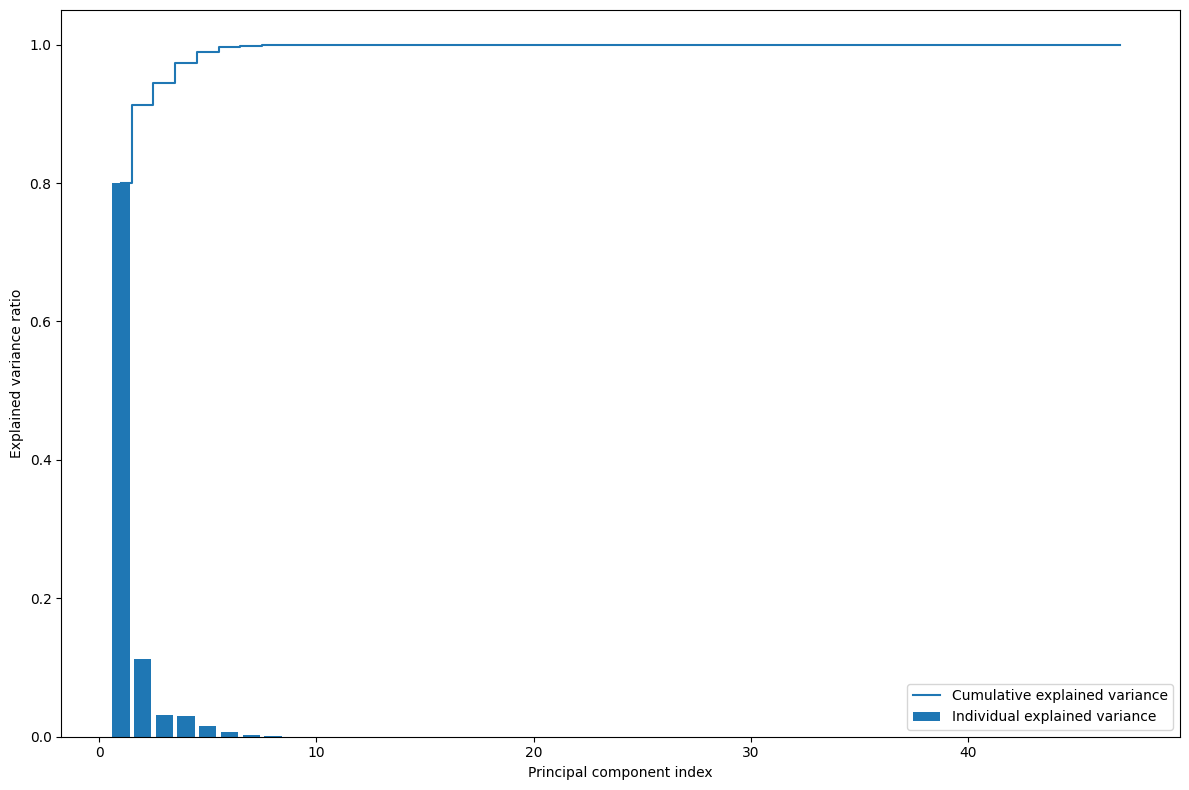

array([0.80016173, 0.9120299 , 0.94391286, 0.97382867, 0.98893059,
       0.99628359, 0.99817661, 0.9993011 , 0.99958968, 0.99974511,
       0.99985348, 0.99993606, 0.99996207, 0.999975  , 0.99998352,
       0.99998969, 0.99999428, 0.9999963 , 0.99999794, 0.99999873,
       0.99999934, 0.99999957, 0.9999997 , 0.9999998 , 0.99999986,
       0.99999991, 0.99999995, 0.99999996, 0.99999997, 0.99999998,
       0.99999999, 0.99999999, 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        ])

In [12]:
# plot the explained variance
vis_ops.plot_explained_variance_ratio(var_exp, cum_var_exp, X_train_fe_scaled.shape[1] + 1)
cum_var_exp

## Explained Variance Ratio Plot

An Explained Variance Ratio Plot is a graphical representation that shows the proportion of the dataset's total variance captured by each principal component after performing Principal Component Analysis (PCA). This plot helps in understanding how much information (variance) each principal component retains from the original dataset.

### What It Represents

- **X-Axis (Principal Components)**: The principal components are listed in order of their importance, from the first principal component (which captures the most variance) to the last.
- **Y-Axis (Explained Variance Ratio)**: The explained variance ratio represents the fraction of the total variance captured by each principal component.

### How It Helps in Reducing Dimensionality

1. **Identify Key Components**: By examining the explained variance ratio plot, you can determine the number of principal components that capture the majority of the variance in the data. Typically, you'll look for the "elbow point" in the plot, where the explained variance starts to level off.
2. **Select Optimal Number of Components**: You can choose the top principal components that account for a significant cumulative variance (e.g., 95% of the total variance). This selection helps in reducing the number of features while preserving most of the important information.
3. **Reduce Overfitting**: By reducing the number of features, the risk of overfitting is minimized, as the model focuses on the most informative components rather than noise or redundant information.
4. **Improve Computational Efficiency**: Fewer features mean lower computational cost for model training and faster execution times, making the analysis more efficient.

### Example Interpretation

Imagine a dataset with 100 features. After applying PCA, you generate an explained variance ratio plot. The plot shows that the first principal component captures 40% of the variance, the second captures 20%, and the third captures 10%. Together, the top three principal components capture 70% of the total variance. Based on this plot, you might decide to reduce the dimensionality of the dataset to these three principal components, significantly simplifying the dataset while retaining most of the important information.


In [13]:
# apply_pca using components
X_train_pca, X_test_pca = pre_ops.apply_pca(X_train_fe_scaled, X_test_fe_scaled, n_components=7)
print(X_train_pca.head())
print()

# fit the model using the pca data
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=1)
lr.fit(X_train_pca, y_train.values.ravel())

# predict the validation set
y_train_pred = lr.predict(X_train_pca)
y_pred_test = lr.predict(X_test_pca)

# calculate the accuracy
print(f"Train Accuracy: {model_ops.calculate_classification_accuracy(y_train, y_train_pred)[3]}")
print(f"Test Accuracy: {model_ops.calculate_classification_accuracy(y_test, y_pred_test)[3]}")

       PC_0      PC_1      PC_2      PC_3      PC_4      PC_5      PC_6
0  3.509594 -0.439387  0.246378  0.753356  0.042010  0.171483  0.037215
1  3.109778 -0.361122  0.127216  0.356458  0.028238  0.048473 -0.036932
2 -1.039960 -0.599062 -0.275238 -0.032737  0.162652 -0.027069 -0.041277
3  3.305727 -0.344442  0.238831  0.595559  0.003693  0.035395 -0.016461
4 -1.074556 -0.822618 -0.249776 -0.098613  0.234488 -0.009555 -0.044153

Train Accuracy: 0.9173854967747753
Test Accuracy: 0.9188361506180447


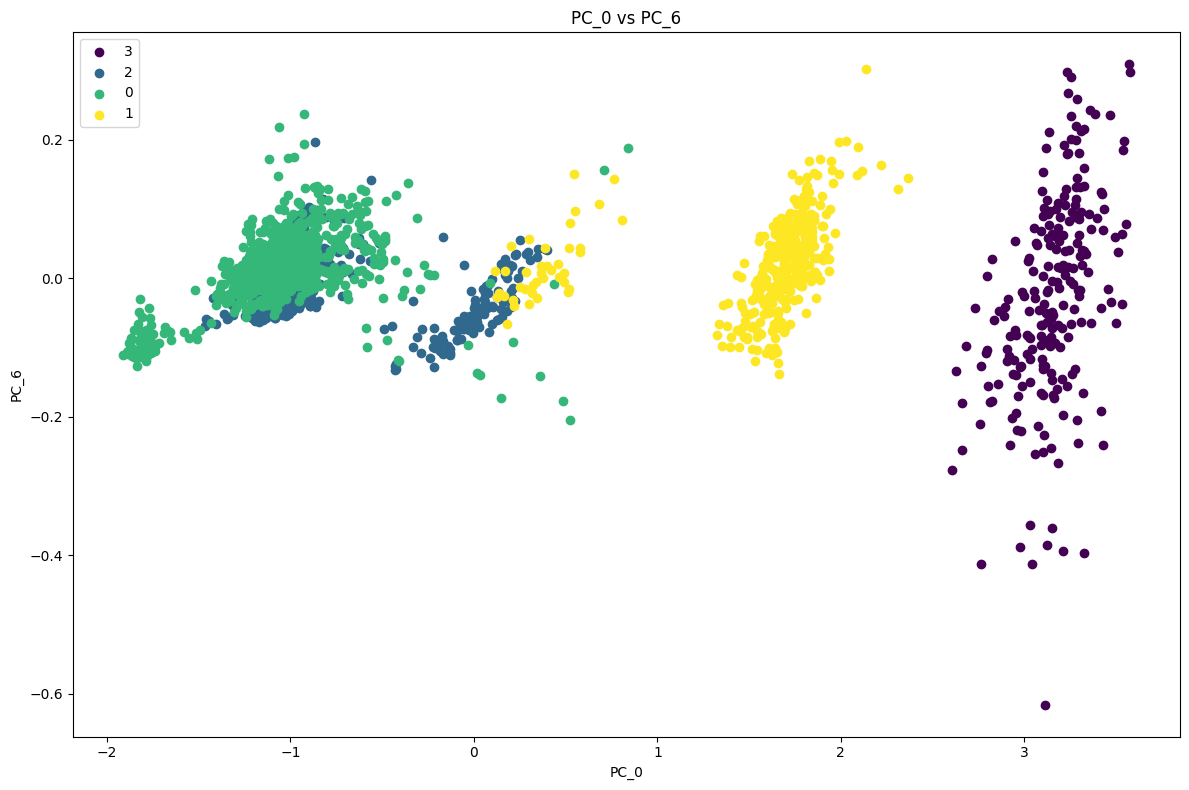

In [14]:
vis_ops.scatter_color_coded(X_train_pca, y_train, "PC_0", "PC_6")

END